In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [2]:
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})

In [3]:
cache_path = './exported_imgs'
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
def save_fig(fname):
    plt.tight_layout()
    out_file = os.path.join(cache_path, fname)
    print(f"save fig => {out_file}")
    plt.savefig(out_file)

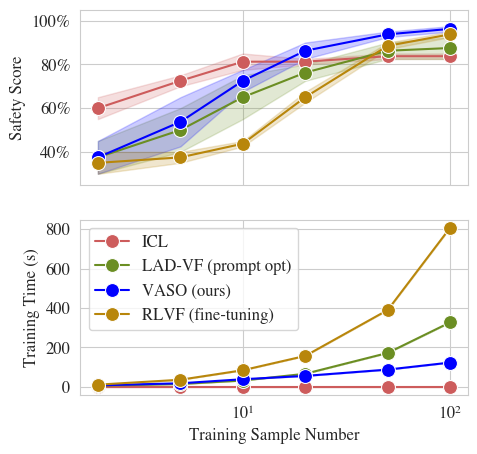

In [4]:
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('results/safe-score-data-size.csv')

df['Category'] = df['Category'].replace('In-Context', 'ICL')
df['Category'] = df['Category'].replace('Prompt Opt (LAD-VF)', 'LAD-VF (prompt opt)')
df['Category'] = df['Category'].replace('VASO (ours)', 'VASO (ours)')
df['Category'] = df['Category'].replace('Fine-tuning (RLVF)', 'RLVF (fine-tuning)')

fig, axs = plt.subplots(2,1, figsize=(5,5), sharex=True)

kwargs = dict(marker='o', markersize=10, palette=['#CD5C5C', '#6B8E23', 'blue', '#B8860B'])

ax = axs[0]
sns.lineplot(df, x='Training Sample Number', y='Safety Score', hue='Category', ax=ax, **kwargs)
ax.set_ylim(0.25, 1.05)
# ax.legend(loc="lower right", ncol = 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))  # format as percentages
ax.legend([],[], frameon=False)
plt.xscale('log')

ax = axs[1]
# ax = sns.lineplot(df, x='Training Sample Number',y='Training Time (s)',hue='Category', marker='o', linestyle='dashed')
sns.lineplot(df, x='Training Sample Number', y='Training Time (s)', hue='Category', ax=ax, **kwargs)
ax.legend(loc="upper left", ncol = 1)
plt.xscale('log')


# save_fig('sample-size-accuracy-n-time.pdf')

/Library/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


save fig => ./exported_imgs/sample-size-accuracy-n-time.pdf


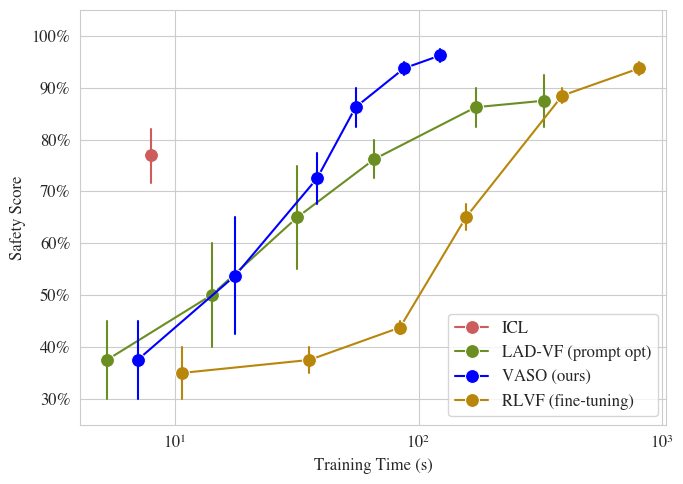

In [5]:
df = pd.read_csv('results/safe-score-data-size.csv')

df['Category'] = df['Category'].replace('In-Context', 'ICL')
df['Category'] = df['Category'].replace('Prompt Opt (LAD-VF)', 'LAD-VF (prompt opt)')
df['Category'] = df['Category'].replace('VASO (ours)', 'VASO (ours)')
df['Category'] = df['Category'].replace('Fine-tuning (RLVF)', 'RLVF (fine-tuning)')

df.loc[df['Category'] == 'ICL', 'Training Time (s)'] = 8

plt.figure(figsize=(7,5))

kwargs = dict(marker='o', markersize=10,
              palette=['#CD5C5C', '#6B8E23', 'blue', '#B8860B'])

sns.lineplot(
    df,
    x='Training Time (s)',
    y='Safety Score',
    hue='Category',
    err_style='bars',
    **kwargs
)

plt.xscale('log')  # optional, but usually still useful
plt.ylim(0.25, 1.05)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))

plt.legend(loc="lower right")
plt.xlabel("Training Time (s)")
plt.ylabel("Safety Score")

plt.tight_layout()
# plt.show()

save_fig('sample-size-accuracy-n-time.pdf')

save fig => ./exported_imgs/safety_optimization_step.pdf


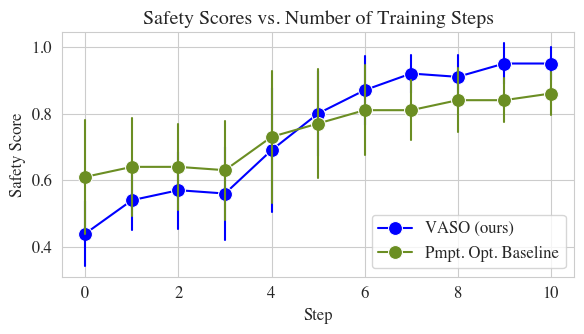

In [4]:
df = pd.read_csv('results/safe-score-step.csv')

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'Times'})

fig, ax = plt.subplots(1,1, figsize=(6,3.5))

kwargs = dict(marker='o', markersize=10, palette=['blue', '#6B8E23'])

ax = sns.lineplot(df, x='Step',y='Safety Score',hue='Category', errorbar='sd', err_style='bars', **kwargs)
ax.set_title('Safety Scores vs. Number of Training Steps')
ax.legend(loc="lower right", ncol = 1)

save_fig('safety_optimization_step.pdf')

save fig => ./exported_imgs/testing_scores.pdf


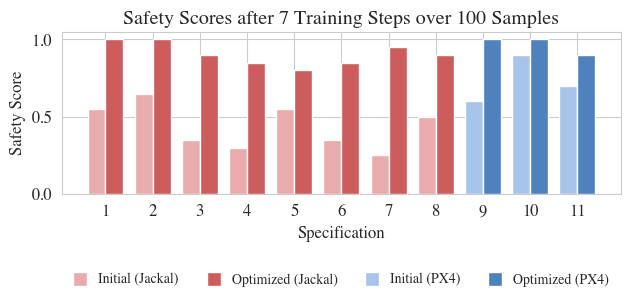

In [5]:
df = pd.read_csv('results/safety-testing.csv')

fig, ax = plt.subplots(1,1, figsize=(6.5,3))

df['Category'] = df['Category'].replace('Step 0', 'Initial Prompt')
df['Category'] = df['Category'].replace('Step 7', 'Final Prompt')
df["Safety Score"] = df["Number of Satisfied Samples"] / 20

# Pivot for easier plotting
plot_df = df.pivot(
    index="Specification",
    columns="Category",
    values="Safety Score"
).sort_index()

x = np.arange(len(plot_df.index))
width = 0.38

# Colors:
# spec 1–10
init_color_1 = "#E9ABAB"
final_color_1 = "#CD5C5C"

# spec 11–15
init_color_2 = "#A9C4EB"
final_color_2 = "#4F81BD"

# Assign colors by specification group
init_colors = [init_color_1 if spec <= 8 else init_color_2 for spec in plot_df.index]
final_colors = [final_color_1 if spec <= 8 else final_color_2 for spec in plot_df.index]

# Draw bars
bars1 = ax.bar(
    x - width/2,
    plot_df["Initial Prompt"],
    width,
    color=init_colors,
    label="Initial Prompt"
)

bars2 = ax.bar(
    x + width/2,
    plot_df["Final Prompt"],
    width,
    color=final_colors,
    label="Final Prompt"
)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_xlabel("Specification")
ax.set_ylabel("Safety Score")
ax.set_title("Safety Scores after 7 Training Steps over 100 Samples")
ax.legend(title="")

# --- Custom legend (4 entries) ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E9ABAB", label="Initial (Jackal)"),
    Patch(facecolor="#CD5C5C", label="Optimized (Jackal)"),
    Patch(facecolor="#A9C4EB", label="Initial (PX4)"),
    Patch(facecolor="#4F81BD", label="Optimized (PX4)")
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.4),  # push below plot
    ncol=4,
    handlelength=1,
    handleheight=1.2,
    fontsize=10,
    frameon=False
)

plt.tight_layout()

save_fig('testing_scores.pdf')